# Week 2 — Exploratory Data Analysis (EDA)

## Junior Data Scientist Internship

### Project: Online Retail Exploratory Data Analysis

**Internship:** Yuva Intern  
**Role:** Junior Data Scientist Intern  
**Week:** 2  
**Dataset:** Online Retail  
**Previous Task:** Week 1 — Data Gathering, Cleaning and Preprocessing

---

## 1. Objective

The objective of this task is to perform a comprehensive Exploratory Data Analysis (EDA) on the cleaned Online Retail dataset prepared during Week 1.

The analysis aims to understand the structure and distribution of the data, uncover hidden patterns and trends, identify relationships between variables, investigate unusual observations, and generate meaningful data-driven insights.

The analysis will include:

- Descriptive statistical analysis
- Measures of central tendency and dispersion
- Univariate analysis
- Bivariate and multivariate analysis
- Distribution analysis
- Histograms and box plots
- Scatter plots
- Correlation analysis and heatmaps
- Time-based trend analysis
- Product and country-level analysis
- Analysis of negative quantity transactions
- Investigation of outlier impact
- Hypothesis testing where statistically appropriate
- Interpretation of statistical results
- Key findings, assumptions, limitations, and implications

---

## 2. Dataset Continuity

The dataset used in this task is the cleaned Online Retail dataset produced during Week 1.

During Week 1, the raw dataset was explored and cleaned by:

- Removing exact duplicate records
- Handling missing product descriptions
- Preserving missing CustomerID values where they could not be reliably inferred
- Converting InvoiceDate to datetime format
- Removing records with UnitPrice less than or equal to zero
- Investigating negative Quantity values
- Investigating statistical outliers

The cleaned dataset contains **534,129 records and 8 columns**.

This Week 2 analysis will build directly on the Week 1 cleaned dataset rather than repeating the complete cleaning process.

---

## 3. Analytical Approach

The EDA will follow a structured analytical workflow:

**Data Loading → Data Validation → Descriptive Statistics → Univariate Analysis → Bivariate Analysis → Multivariate Analysis → Trend Analysis → Statistical Testing → Interpretation → Key Insights**

For important findings, the analysis will follow:

**Observation → Interpretation → Implication**

This approach is intended to ensure that visualizations and statistical outputs are not presented without context.

---

## 4. Special Analytical Considerations

### Negative Quantity Transactions

Negative Quantity values will be investigated rather than automatically removed.

Such records may represent returns, cancellations, or transaction reversals. Their frequency, proportion, quantity, revenue impact, and distribution will be examined separately.

The analysis will also consider the implication of including these transactions in overall sales calculations.

### Outliers

Extreme observations will be investigated using statistical methods such as the Interquartile Range (IQR).

Outliers will not be removed automatically because extreme retail transactions may represent legitimate business activity such as bulk purchases.

Where appropriate, the analysis will compare the effect of extreme observations on statistical measures such as mean and median.

---

## 5. Statistical Analysis

The analysis will use appropriate descriptive statistics including:

- Mean
- Median
- Mode where meaningful
- Minimum and maximum
- Range
- Variance
- Standard deviation
- Quartiles
- Interquartile Range (IQR)
- Percentiles
- Skewness where useful

Where an appropriate research question can be formulated, hypothesis testing will be performed using a statistically suitable test.

The choice of statistical test will depend on the characteristics and assumptions of the variables being compared.

---

## 6. Expected Outcomes

The analysis is expected to identify:

- Major patterns in retail transactions
- Distribution of quantities and prices
- High-value transactions
- Product-level patterns
- Country-level differences
- Time-based sales trends
- Relationships between important numerical variables
- Potential effects of returns or cancellations
- The influence of extreme observations
- Statistically meaningful relationships where applicable

The final findings will be documented with appropriate visualizations, statistical evidence, explanations, assumptions, limitations, and practical implications.

In [25]:
# ============================================
# Week 2 — Exploratory Data Analysis
# Step 3: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [26]:
import sys
!{sys.executable} -m pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from pathlib import Path

In [28]:
# ============================================
# Step 4: Load Week 1 Cleaned Dataset
# ============================================

# Path to the cleaned dataset created in Week 1
data_path = Path("../data/cleaned/Online_Retail_Cleaned.csv")

# Load dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 534,129
Columns: 8


In [29]:
# ============================================
# Step 5: Initial Data Validation
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(534129, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132565
Country             0
dtype: int64

Duplicate Rows:
0


In [30]:
# ============================================
# Step 6: First Look at the Dataset
# ============================================

print("First 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

print("\nRandom Sample of 5 Records:")
display(df.sample(5, random_state=42))

First 5 Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom



Last 5 Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
534124,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,"12,680.00",France
534125,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France
534126,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France
534127,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France
534128,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France



Random Sample of 5 Records:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
80912,543188,21039,RED RETROSPOT SHOPPING BAG,6,2011-02-04 11:45:00,2.55,"12,567.00",France
494000,578824,23121,PACK OF 6 COCKTAIL PARASOL STRAWS,5,2011-11-25 14:02:00,0.42,"17,883.00",United Kingdom
159420,550492,22427,ENAMEL FLOWER JUG CREAM,3,2011-04-18 14:44:00,5.95,"14,180.00",United Kingdom
250261,559174,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-07 10:04:00,1.25,"18,263.00",United Kingdom
231782,557626,20675,BLUE POLKADOT BOWL,8,2011-06-21 14:29:00,1.25,"14,175.00",United Kingdom


In [31]:
# ============================================
# Step 7: Descriptive Statistics
# ============================================

# Select important numerical variables
numeric_cols = ["Quantity", "UnitPrice"]

# Generate descriptive statistics
descriptive_stats = df[numeric_cols].describe().T

# Add additional statistical measures
descriptive_stats["median"] = df[numeric_cols].median()
descriptive_stats["variance"] = df[numeric_cols].var()
descriptive_stats["skewness"] = df[numeric_cols].skew()
descriptive_stats["IQR"] = (
    df[numeric_cols].quantile(0.75)
    - df[numeric_cols].quantile(0.25)
)

# Reorder columns for readability
descriptive_stats = descriptive_stats[
    [
        "count",
        "mean",
        "median",
        "std",
        "variance",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "IQR",
        "skewness"
    ]
]

display(descriptive_stats)

,count,mean,median,std,variance,min,25%,50%,75%,max,IQR,skewness
Quantity,"534,129.00",9.92,3.00,216.45,"46,851.52","-80,995.00",1.00,3.00,10.00,"80,995.00",9.00,-0.12
UnitPrice,"534,129.00",4.70,2.10,95.08,"9,040.05",0.00,1.25,2.10,4.13,"38,970.00",2.88,205.34


In [32]:
# ============================================
# Step 8: Create Transaction Revenue
# ============================================

# Calculate transaction-level revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Revenue variable created successfully.")

print("\nRevenue Summary:")
display(df["Revenue"].describe())

print("\nSample Records:")
display(df[["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]].head())

Revenue variable created successfully.

Revenue Summary:


count    534,129.00
mean          18.25
std          380.95
min     -168,469.60
25%            3.75
50%            9.90
75%           17.57
max      168,469.60
Name: Revenue, dtype: float64


Sample Records:


,InvoiceNo,Quantity,UnitPrice,Revenue
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


In [33]:
# ============================================
# Step 9: Negative Quantity Analysis
# ============================================

# Separate positive and negative quantity transactions
negative_qty = df[df["Quantity"] < 0]
positive_qty = df[df["Quantity"] > 0]

# Basic counts
total_records = len(df)
negative_count = len(negative_qty)
positive_count = len(positive_qty)

negative_percentage = (negative_count / total_records) * 100

print("Negative Quantity Analysis")
print("=" * 40)

print(f"Total transactions: {total_records:,}")
print(f"Positive Quantity transactions: {positive_count:,}")
print(f"Negative Quantity transactions: {negative_count:,}")
print(f"Negative Quantity percentage: {negative_percentage:.2f}%")

print("\nNegative Quantity Statistics:")
display(
    negative_qty[["Quantity", "UnitPrice", "Revenue"]].describe()
)

print("\nNegative Quantity Revenue:")
print(f"Total negative revenue: {negative_qty['Revenue'].sum():,.2f}")

print("\nPositive Quantity Revenue:")
print(f"Total positive revenue: {positive_qty['Revenue'].sum():,.2f}")

Negative Quantity Analysis
Total transactions: 534,129
Positive Quantity transactions: 524,878
Negative Quantity transactions: 9,251
Negative Quantity percentage: 1.73%

Negative Quantity Statistics:


,Quantity,UnitPrice,Revenue
count,"9,251.00","9,251.00","9,251.00"
mean,-29.79,48.57,-96.64
std,"1,148.00",667.93,"2,043.92"
min,"-80,995.00",0.01,"-168,469.60"
25%,-6.00,1.45,-17.70
50%,-2.00,2.95,-8.50
75%,-1.00,5.95,-3.70
max,-1.00,"38,970.00",-0.12



Negative Quantity Revenue:
Total negative revenue: -893,979.73

Positive Quantity Revenue:
Total positive revenue: 10,642,110.80


In [34]:
# ============================================
# Step 10: Negative Quantity by Country
# ============================================

negative_by_country = (
    negative_qty
    .groupby("Country")
    .agg(
        Negative_Transactions=("InvoiceNo", "count"),
        Negative_Quantity=("Quantity", "sum"),
        Negative_Revenue=("Revenue", "sum")
    )
    .sort_values("Negative_Transactions", ascending=False)
)

print("Top 15 Countries by Negative-Quantity Transactions:")
display(negative_by_country.head(15))

Top 15 Countries by Negative-Quantity Transactions:


,Negative_Transactions,Negative_Quantity,Negative_Revenue
Country,,,
United Kingdom,7821,-261044,"-812,491.79"
Germany,453,-1815,"-7,168.93"
EIRE,301,-4786,"-20,147.14"
France,148,-1623,"-12,308.26"
USA,112,-1424,"-1,849.47"
Australia,74,-556,"-1,444.04"
Spain,48,-1127,"-6,802.53"
Italy,45,-113,-592.73
Belgium,38,-85,-285.38


In [35]:
# ============================================
# Step 11: Product-level Negative Quantity Analysis
# ============================================

negative_by_product = (
    negative_qty
    .groupby(["StockCode", "Description"])
    .agg(
        Return_Transactions=("InvoiceNo", "count"),
        Total_Returned_Quantity=("Quantity", "sum"),
        Return_Revenue_Impact=("Revenue", "sum")
    )
    .sort_values("Return_Transactions", ascending=False)
)

print("Top 15 Products by Negative-Quantity Transactions:")
display(negative_by_product.head(15))

Top 15 Products by Negative-Quantity Transactions:


,,Return_Transactions,Total_Returned_Quantity,Return_Revenue_Impact
StockCode,Description,,,
M,Manual,244,-4066,"-146,784.46"
22423,REGENCY CAKESTAND 3 TIER,180,-855,"-9,697.05"
POST,POSTAGE,126,-147,"-11,871.24"
22960,JAM MAKING SET WITH JARS,87,-247,"-1,012.79"
D,Discount,77,-1194,"-5,696.22"
22720,SET OF 3 CAKE TINS PANTRY DESIGN,73,-154,-730.10
S,SAMPLES,60,-60,"-3,102.70"
22699,ROSES REGENCY TEACUP AND SAUCER,54,-437,"-1,150.35"
21232,STRAWBERRY CERAMIC TRINKET BOX,54,-362,-414.50


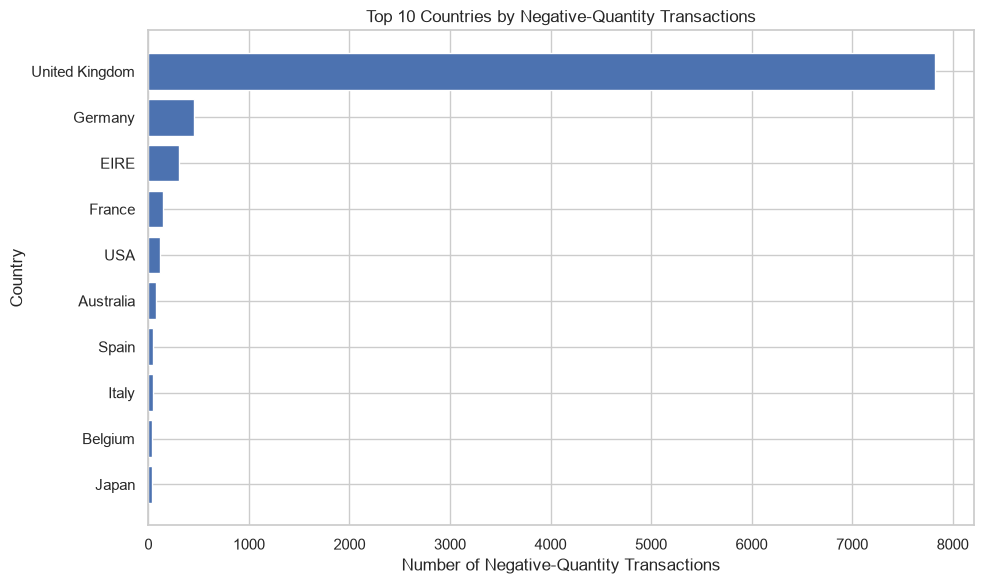

In [36]:
# ============================================
# Step 12: Negative Quantity Visualization
# ============================================

top_negative_countries = (
    negative_by_country
    .head(10)
    .sort_values("Negative_Transactions")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_countries.index,
    top_negative_countries["Negative_Transactions"]
)

plt.xlabel("Number of Negative-Quantity Transactions")
plt.ylabel("Country")
plt.title("Top 10 Countries by Negative-Quantity Transactions")

plt.tight_layout()
plt.show()

### Observation

The chart shows the countries with the highest number of transactions containing negative quantities. The distribution indicates whether negative-quantity transactions are concentrated in a small number of countries or distributed across multiple countries.

### Interpretation

Negative quantities should not automatically be treated as invalid observations because they may represent returns, cancellations, or transaction reversals. The country-level distribution provides additional context for evaluating this interpretation.

### Analytical Implication

Retaining negative quantities preserves potentially meaningful transaction information. However, analyses that measure gross sales or sales volume should distinguish regular sales from negative-quantity transactions to avoid mixing sales and reversal activity.

In [37]:
# ============================================
# Step 13: Outlier Detection using IQR
# ============================================

# Function to calculate IQR-based outliers
def iqr_outlier_summary(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": (len(outliers) / len(data)) * 100
    }


# Analyze Quantity
quantity_outliers = iqr_outlier_summary(df, "Quantity")

# Analyze UnitPrice
unitprice_outliers = iqr_outlier_summary(df, "UnitPrice")

# Analyze Revenue
revenue_outliers = iqr_outlier_summary(df, "Revenue")


# Display results
outlier_summary = pd.DataFrame(
    [quantity_outliers, unitprice_outliers, revenue_outliers],
    index=["Quantity", "UnitPrice", "Revenue"]
)

display(outlier_summary)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
Quantity,1.00,10.00,9.00,-12.50,23.50,57326,10.73
UnitPrice,1.25,4.13,2.88,-3.07,8.45,39448,7.39
Revenue,3.75,17.57,13.82,-16.98,38.30,45114,8.45


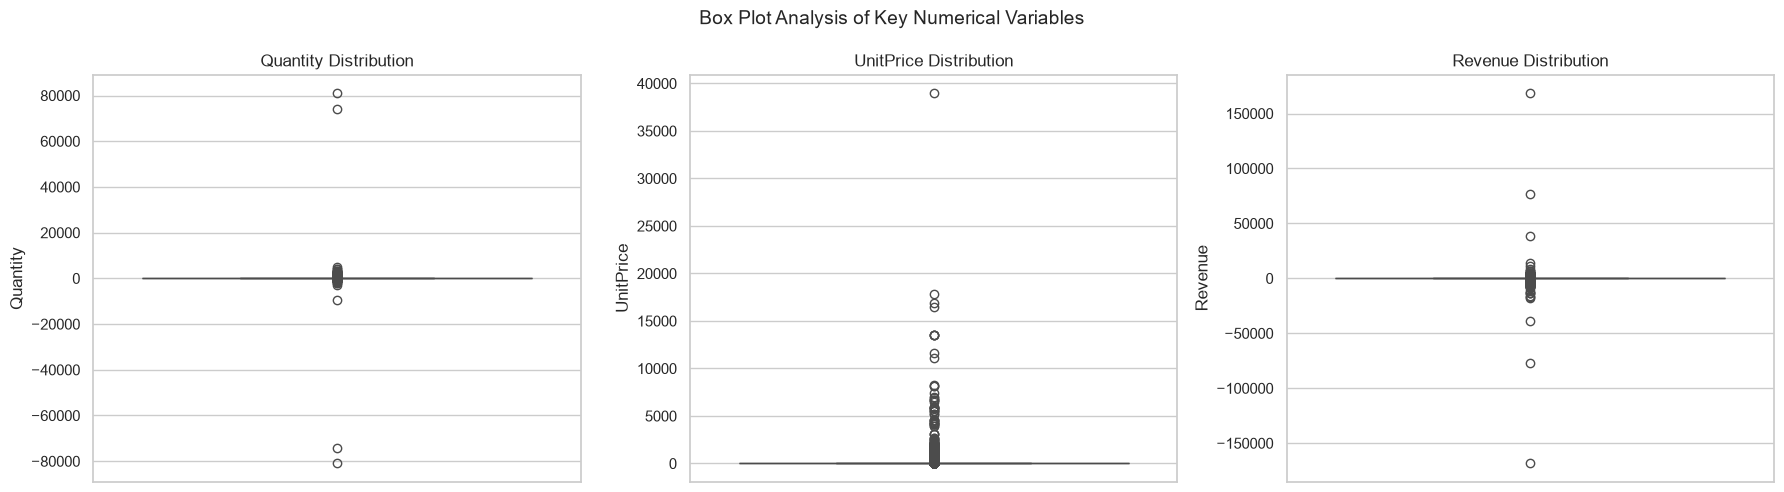

In [38]:
# ============================================
# Step 14: Box Plot Analysis
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantity
sns.boxplot(y=df["Quantity"], ax=axes[0])
axes[0].set_title("Quantity Distribution")
axes[0].set_ylabel("Quantity")

# UnitPrice
sns.boxplot(y=df["UnitPrice"], ax=axes[1])
axes[1].set_title("UnitPrice Distribution")
axes[1].set_ylabel("UnitPrice")

# Revenue
sns.boxplot(y=df["Revenue"], ax=axes[2])
axes[2].set_title("Revenue Distribution")
axes[2].set_ylabel("Revenue")

plt.suptitle("Box Plot Analysis of Key Numerical Variables", fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
# ============================================
# Step 15: Outlier Impact Analysis
# Mean vs Median
# ============================================

# Calculate original statistics
original_stats = pd.DataFrame({
    "Mean": [
        df["Quantity"].mean(),
        df["UnitPrice"].mean(),
        df["Revenue"].mean()
    ],
    "Median": [
        df["Quantity"].median(),
        df["UnitPrice"].median(),
        df["Revenue"].median()
    ]
}, index=["Quantity", "UnitPrice", "Revenue"])


# Remove IQR-based extreme values temporarily
# This is ONLY for impact comparison — not permanent deletion.

def remove_iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[
        (data[column] >= lower) &
        (data[column] <= upper)
    ]


quantity_no_outliers = remove_iqr_outliers(df, "Quantity")
unitprice_no_outliers = remove_iqr_outliers(df, "UnitPrice")
revenue_no_outliers = remove_iqr_outliers(df, "Revenue")


impact_stats = pd.DataFrame({
    "Variable": ["Quantity", "UnitPrice", "Revenue"],
    "Original Mean": [
        df["Quantity"].mean(),
        df["UnitPrice"].mean(),
        df["Revenue"].mean()
    ],
    "Original Median": [
        df["Quantity"].median(),
        df["UnitPrice"].median(),
        df["Revenue"].median()
    ],
    "Mean After IQR Filtering": [
        quantity_no_outliers["Quantity"].mean(),
        unitprice_no_outliers["UnitPrice"].mean(),
        revenue_no_outliers["Revenue"].mean()
    ],
    "Median After IQR Filtering": [
        quantity_no_outliers["Quantity"].median(),
        unitprice_no_outliers["UnitPrice"].median(),
        revenue_no_outliers["Revenue"].median()
    ]
})

display(impact_stats)

,Variable,Original Mean,Original Median,Mean After IQR Filtering,Median After IQR Filtering
0,Quantity,9.92,3.00,4.61,3.00
1,UnitPrice,4.70,2.10,2.54,1.95
2,Revenue,18.25,9.90,10.30,8.29


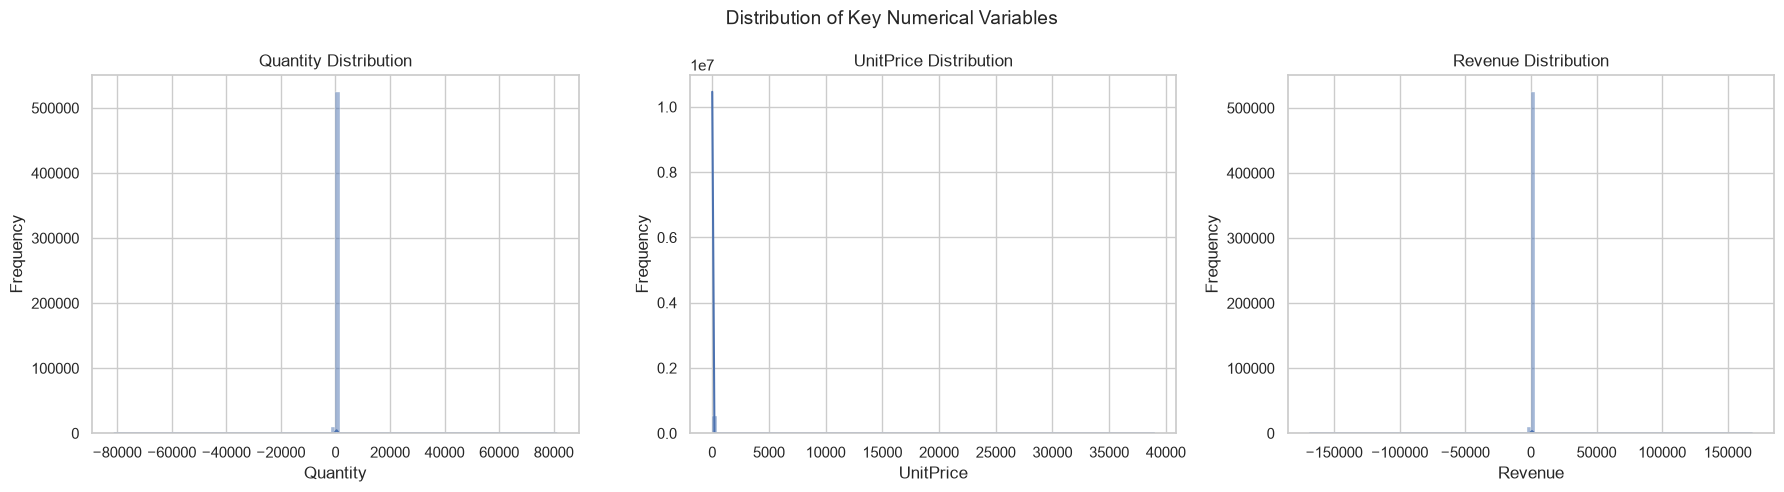

In [40]:
# ============================================
# Step 16: Distribution Analysis
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantity distribution
sns.histplot(
    df["Quantity"],
    bins=100,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Quantity Distribution")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

# UnitPrice distribution
sns.histplot(
    df["UnitPrice"],
    bins=100,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("UnitPrice Distribution")
axes[1].set_xlabel("UnitPrice")
axes[1].set_ylabel("Frequency")

# Revenue distribution
sns.histplot(
    df["Revenue"],
    bins=100,
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Revenue Distribution")
axes[2].set_xlabel("Revenue")
axes[2].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Key Numerical Variables",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Distribution Analysis — Observations and Inferences

**Quantity:**  
_To be interpreted after reviewing the histogram._

**UnitPrice:**  
_To be interpreted after reviewing the histogram._

**Revenue:**  
_To be interpreted after reviewing the histogram._

**Implication:**  
_The distribution shape will determine whether mean, median, transformations, or additional outlier investigation should receive greater emphasis._

Correlation Matrix:


,Quantity,UnitPrice,Revenue
Quantity,1.00,-0.00,0.90
UnitPrice,-0.00,1.00,-0.18
Revenue,0.90,-0.18,1.00


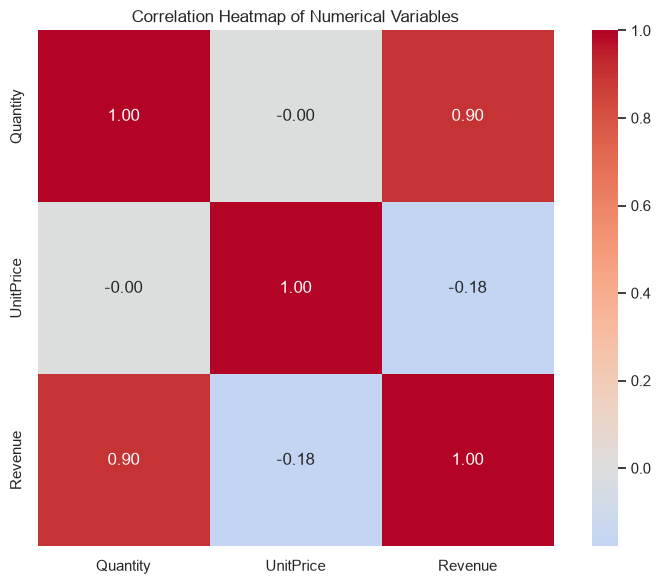

In [41]:
# ============================================
# Step 17: Correlation Analysis
# ============================================

# Select numerical variables
correlation_cols = [
    "Quantity",
    "UnitPrice",
    "Revenue"
]

correlation_matrix = df[correlation_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Analysis — Interpretation

The correlation matrix is used to examine the strength and direction of linear relationships between Quantity, UnitPrice, and Revenue.

Correlation values close to +1 indicate a strong positive linear association, values close to -1 indicate a strong negative linear association, and values close to 0 indicate a weak linear association.

The results will be interpreted in the context of the retail transaction data. Correlation will be treated as an association rather than evidence of causation.

Particular attention will be given to the relationship between Quantity and Revenue, because Revenue is derived from Quantity × UnitPrice. Therefore, any observed correlation involving Revenue should be interpreted with this mathematical relationship in mind.

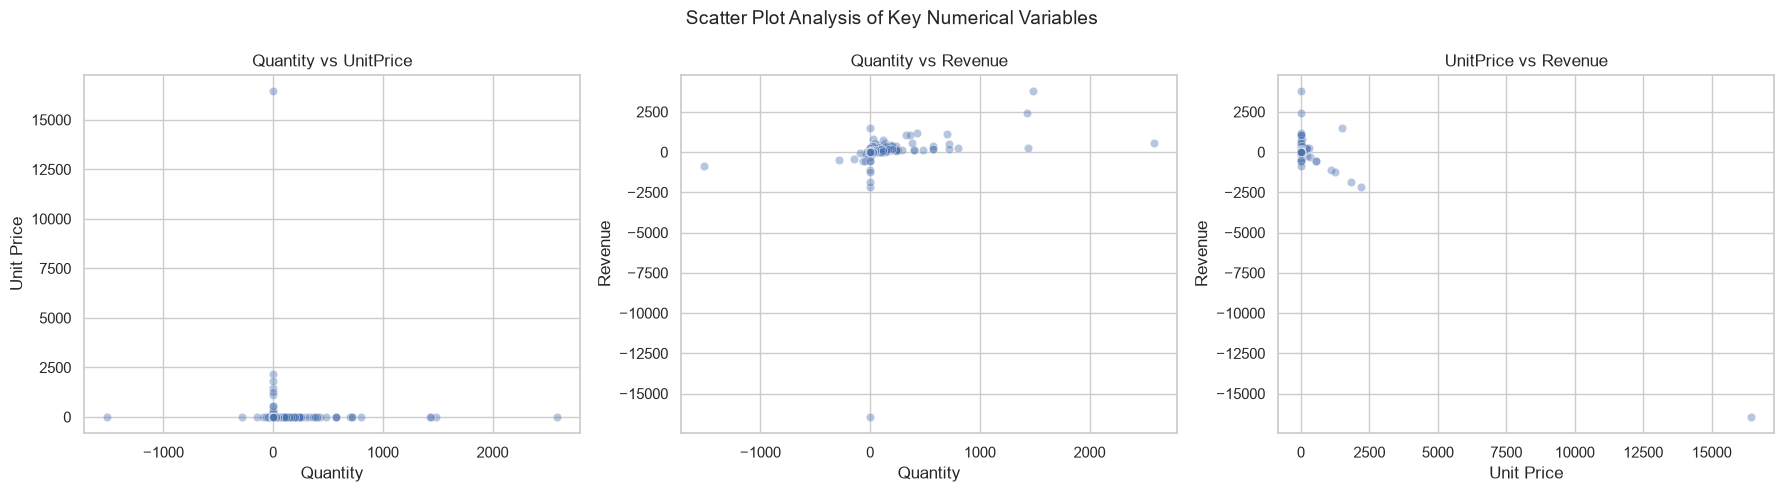

In [42]:
# ============================================
# Step 18: Scatter Plot Analysis
# ============================================

# Sample data to improve visualization performance
sample_df = df.sample(
    min(10000, len(df)),
    random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Quantity vs UnitPrice
sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="UnitPrice",
    alpha=0.4,
    ax=axes[0]
)

axes[0].set_title("Quantity vs UnitPrice")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Unit Price")


# Quantity vs Revenue
sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="Revenue",
    alpha=0.4,
    ax=axes[1]
)

axes[1].set_title("Quantity vs Revenue")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Revenue")


# UnitPrice vs Revenue
sns.scatterplot(
    data=sample_df,
    x="UnitPrice",
    y="Revenue",
    alpha=0.4,
    ax=axes[2]
)

axes[2].set_title("UnitPrice vs Revenue")
axes[2].set_xlabel("Unit Price")
axes[2].set_ylabel("Revenue")


plt.suptitle(
    "Scatter Plot Analysis of Key Numerical Variables",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Scatter Plot Analysis — Observations and Inferences

**Quantity vs UnitPrice:**  
The scatter plot is used to examine whether transaction quantity and unit price show a meaningful linear relationship. The distribution should be interpreted carefully because retail products can have very different prices and quantities.

**Quantity vs Revenue:**  
A relationship between Quantity and Revenue is expected because Revenue is mathematically calculated as Quantity × UnitPrice. Therefore, the observed relationship should not be interpreted as an independent causal relationship.

**UnitPrice vs Revenue:**  
Revenue is also mathematically dependent on UnitPrice. Therefore, a positive association between UnitPrice and Revenue can occur partly because of the revenue calculation itself.

**Analytical Implication:**  
Scatter plots help identify concentration, dispersion, extreme transactions, and potential nonlinear patterns. However, the mathematical construction of Revenue must be considered when interpreting correlations involving Revenue.

In [43]:
# ============================================
# Step 19: Time-Based Analysis
# ============================================

# Make sure InvoiceDate is in datetime format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create time-based features
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

# Positive-quantity transactions represent regular sales activity
positive_sales = df[df["Quantity"] > 0].copy()

# Monthly sales
monthly_sales = (
    positive_sales
    .groupby("YearMonth")
    .agg(
        Transactions=("InvoiceNo", "count"),
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)

print("Monthly Sales Summary:")
display(monthly_sales)

Monthly Sales Summary:


,YearMonth,Transactions,Revenue,Quantity
0,2010-12,40991,"821,452.73",358019
1,2011-01,34060,"689,811.61",387099
2,2011-02,26882,"522,545.56",282934
3,2011-03,35497,"716,215.26",376599
4,2011-04,28882,"536,968.49",307953
5,2011-05,35917,"769,296.61",395001
6,2011-06,35716,"760,547.01",388511
7,2011-07,38395,"718,076.12",399693
8,2011-08,34264,"757,841.38",421020
9,2011-09,48900,"1,056,435.19",569573


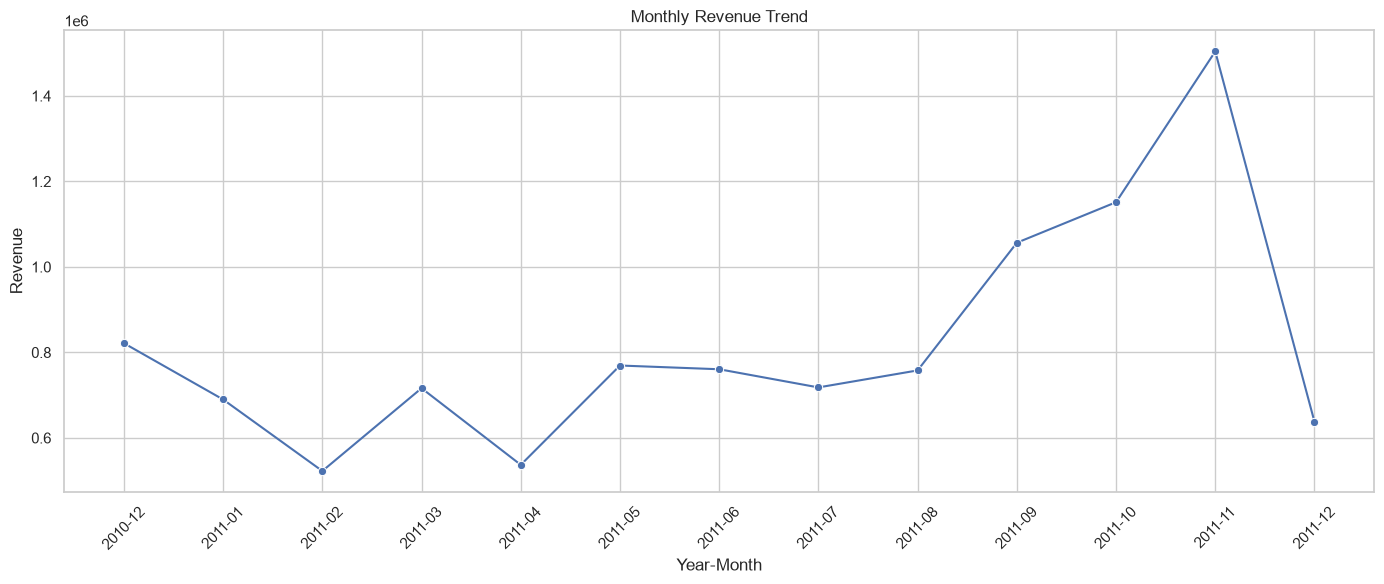

In [44]:
# ============================================
# Monthly Revenue Trend
# ============================================

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="YearMonth",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
# ============================================
# Day-of-Week Transaction Analysis
# ============================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_analysis = (
    positive_sales
    .groupby("DayOfWeek")
    .agg(
        Transactions=("InvoiceNo", "count"),
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reindex(day_order)
)

print("Day-of-Week Analysis:")
display(daily_analysis)

Day-of-Week Analysis:


,Transactions,Revenue,Quantity
DayOfWeek,,,
Monday,"92,466.00","1,775,782.07","871,148.00"
Tuesday,"98,726.00","2,175,700.51","1,113,087.00"
Wednesday,"91,467.00","1,847,074.38","1,025,093.00"
Thursday,"100,213.00","2,199,292.57","1,207,384.00"
Friday,"79,667.00","1,837,470.49","890,199.00"
Saturday,NaN,NaN,NaN
Sunday,"62,339.00","806,790.78","465,509.00"


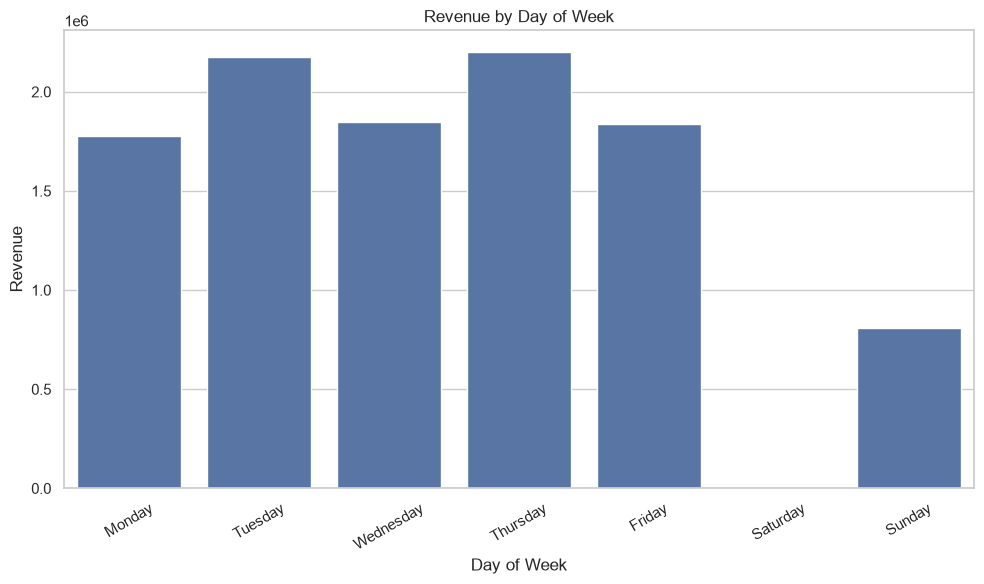

In [46]:
# ============================================
# Day-of-Week Revenue Visualization
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    x=daily_analysis.index,
    y=daily_analysis["Revenue"]
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Time-Based Analysis — Observations and Inferences

**Monthly Revenue Trend:**  
The monthly revenue trend helps identify changes in sales activity over the observation period. Peaks and declines may indicate changes in transaction volume, purchasing behaviour, or seasonal patterns.

**Day-of-Week Pattern:**  
The day-of-week analysis shows how transaction activity and revenue are distributed across different days.

**Analytical Decision:**  
Positive-quantity transactions are used for the regular sales trend because negative quantities may represent returns, cancellations, or reversals. Negative-quantity transactions are analyzed separately rather than being treated as ordinary sales.

**Limitation:**  
The observed time patterns describe this particular dataset and observation period. They should not automatically be generalized to all retail businesses or future periods.

In [47]:
# ============================================
# Step 20A: Top Products by Revenue
# ============================================

top_products = (
    positive_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Transactions=("InvoiceNo", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

print("Top 15 Products by Revenue:")
display(top_products.head(15))

Top 15 Products by Revenue:


,,Transactions,Quantity_Sold,Revenue
StockCode,Description,,,
DOT,DOTCOM POSTAGE,706,706,"206,248.77"
22423,REGENCY CAKESTAND 3 TIER,2007,13851,"174,156.54"
23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,"168,469.60"
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2244,37580,"104,284.24"
47566,PARTY BUNTING,1699,18283,"99,445.23"
85099B,JUMBO BAG RED RETROSPOT,2109,48371,"94,159.81"
23166,MEDIUM CERAMIC TOP STORAGE JAR,250,78033,"81,700.92"
POST,POSTAGE,1126,3150,"78,101.88"
M,Manual,316,6984,"77,750.27"


In [48]:
# ============================================
# Top 10 Products by Revenue Visualization
# ============================================

top_10_products = (
    top_products
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_products["Description"].astype(str),
    top_10_products["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

KeyError: 'Description'

<Figure size 1200x700 with 0 Axes>

In [ ]:
# ============================================
# Step 20A: Top Products by Revenue
# ============================================

top_products = (
    positive_sales
    .groupby(["StockCode", "Description"])
    .agg(
        Transactions=("InvoiceNo", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

print("Top 15 Products by Revenue:")
display(top_products.head(15))

Top 15 Products by Revenue:


,StockCode,Description,Transactions,Quantity_Sold,Revenue
4150,DOT,DOTCOM POSTAGE,706,706,206248.77
1340,22423,REGENCY CAKESTAND 3 TIER,2007,13851,174156.54
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2244,37580,104284.24
2877,47566,PARTY BUNTING,1699,18283,99445.23
3619,85099B,JUMBO BAG RED RETROSPOT,2109,48371,94159.81
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,250,78033,81700.92
4153,POST,POSTAGE,1126,3150,78101.88
4151,M,Manual,316,6984,77750.27
2029,23084,RABBIT NIGHT LIGHT,1017,30739,66870.03


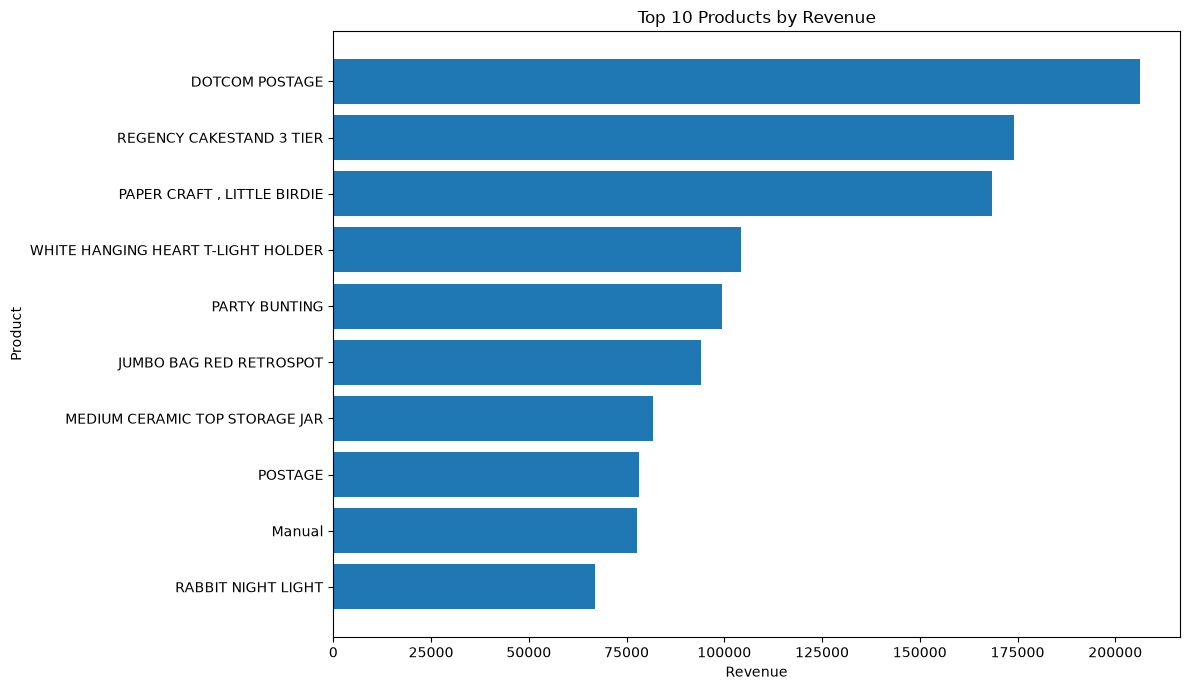

In [ ]:
# ============================================
# Top 10 Products by Revenue Visualization
# ============================================

top_10_products = (
    top_products
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_products["Description"].astype(str),
    top_10_products["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Step 20B: Country-wise Sales Analysis
# ============================================

country_sales = (
    positive_sales
    .groupby("Country")
    .agg(
        Transactions=("InvoiceNo", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

print("Top 15 Countries by Revenue:")
display(country_sales.head(15))

Top 15 Countries by Revenue:


,Country,Transactions,Quantity_Sold,Revenue
36,United Kingdom,479985,4646906,9001744.094
24,Netherlands,2359,200361,285446.340
10,EIRE,7879,147007,283140.520
14,Germany,9025,119154,228678.400
13,France,8392,112060,209625.370
0,Australia,1181,83891,138453.810
31,Spain,2479,27933,61558.560
33,Switzerland,1958,30617,57067.600
3,Belgium,2031,23237,41196.340
32,Sweden,450,36078,38367.830


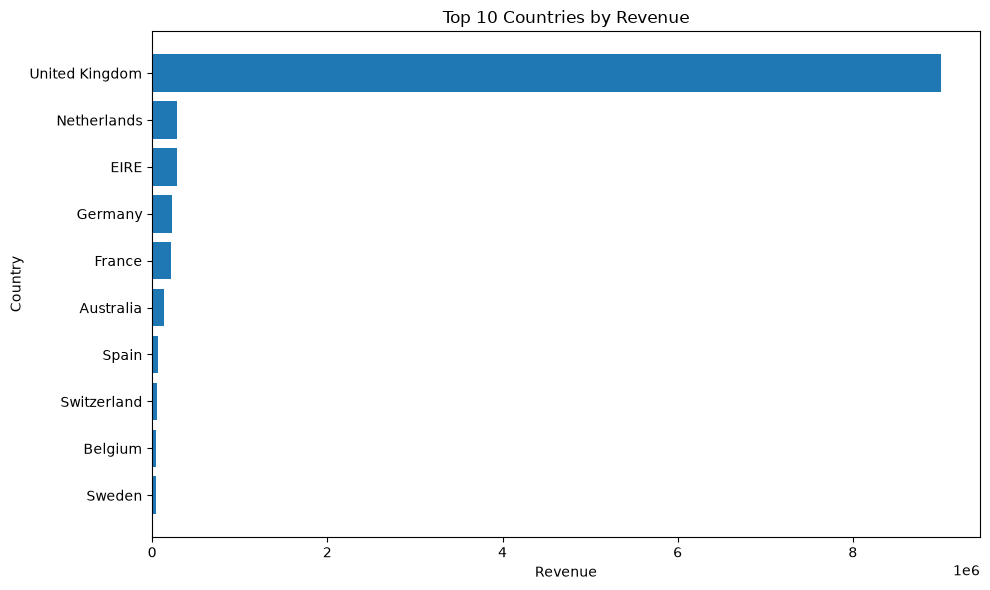

In [ ]:
# ============================================
# Top 10 Countries by Revenue Visualization
# ============================================

top_10_countries = (
    country_sales
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries["Country"],
    top_10_countries["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")

plt.tight_layout()
plt.show()

### Product and Country-Level Analysis — Observations and Inferences

**Top Products:**  
The product-level analysis identifies products generating the highest recorded revenue from positive-quantity transactions. Revenue concentration among a small number of products may indicate that certain products contribute disproportionately to overall sales.

**Country-Level Performance:**  
The country-level analysis shows how revenue and transaction activity are distributed across different markets. Differences between countries may reflect differences in transaction volume, customer base, product demand, or purchasing behaviour.

**Analytical Implication:**  
Product and country-level analysis helps identify major contributors to recorded sales and provides areas for further investigation.

**Important Limitation:**  
Revenue does not represent profit because product costs, discounts, shipping costs, and other expenses are not available in the dataset. Therefore, high revenue should not automatically be interpreted as high profitability.

**Data Handling Note:**  
Negative-quantity transactions were excluded from this regular-sales analysis because they may represent returns, cancellations, or reversals. They were analyzed separately earlier in the notebook.

In [ ]:
# ============================================
# Step 21: Customer Analysis & AOV
# ============================================

# Keep only records with a known CustomerID
customer_sales = positive_sales[
    positive_sales["CustomerID"].notna()
].copy()

# Calculate order-level revenue
order_level = (
    customer_sales
    .groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Order_Revenue=("Revenue", "sum"),
        Items=("Quantity", "sum")
    )
    .reset_index()
)

# Customer-level metrics
customer_analysis = (
    order_level
    .groupby("CustomerID")
    .agg(
        Number_of_Orders=("InvoiceNo", "nunique"),
        Total_Items=("Items", "sum"),
        Total_Revenue=("Order_Revenue", "sum")
    )
    .reset_index()
)

# Average Order Value for each customer
customer_analysis["AOV"] = (
    customer_analysis["Total_Revenue"]
    / customer_analysis["Number_of_Orders"]
)

print("Customer Analysis Summary:")
display(customer_analysis.describe())

Customer Analysis Summary:


,CustomerID,Number_of_Orders,Total_Items,Total_Revenue,AOV
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,4.272015,1187.644537,2048.688081,417.645735
std,1721.808492,7.697998,5043.619654,8985.230220,1796.511343
min,12346.000000,1.000000,1.000000,3.750000,3.450000
25%,13813.250000,1.000000,159.000000,306.482500,177.867083
50%,15299.500000,2.000000,378.000000,668.570000,291.940000
75%,16778.750000,5.000000,989.750000,1660.597500,428.280625
max,18287.000000,209.000000,196915.000000,280206.020000,84236.250000


In [ ]:
# ============================================
# Overall Average Order Value
# ============================================

total_revenue = order_level["Order_Revenue"].sum()
total_orders = order_level["InvoiceNo"].nunique()

overall_aov = total_revenue / total_orders

print(f"Total Revenue from identified customers: {total_revenue:,.2f}")
print(f"Total Orders from identified customers: {total_orders:,}")
print(f"Average Order Value (AOV): {overall_aov:,.2f}")

Total Revenue from identified customers: 8,887,208.89
Total Orders from identified customers: 18,532
Average Order Value (AOV): 479.56


In [ ]:
# ============================================
# Top 15 Customers by Revenue
# ============================================

top_customers = (
    customer_analysis
    .sort_values("Total_Revenue", ascending=False)
    .head(15)
)

print("Top 15 Customers by Revenue:")
display(top_customers)

Top 15 Customers by Revenue:


,CustomerID,Number_of_Orders,Total_Items,Total_Revenue,AOV
1689,14646.0,73,196915,280206.02,3838.438630
4201,18102.0,60,64124,259657.30,4327.621667
3728,17450.0,46,69973,194390.79,4225.886739
3008,16446.0,2,80997,168472.50,84236.250000
1879,14911.0,201,80240,143711.17,714.980945
55,12415.0,21,77374,124914.53,5948.310952
1333,14156.0,55,57768,117210.08,2131.092364
3771,17511.0,31,64549,91062.38,2937.496129
2702,16029.0,63,40108,80850.84,1283.346667
0,12346.0,1,74215,77183.60,77183.600000


In [ ]:
### Customer Analysis — Observations and Inferences

**Customer Coverage:**  
Customer-level analysis is restricted to transactions with a known CustomerID. Records without a CustomerID are retained in the dataset but cannot be reliably assigned to an individual customer.

**Average Order Value (AOV):**  
AOV is calculated at the invoice level rather than the individual transaction-line level. This provides a more meaningful estimate of the average value of a customer's order.

**Customer Revenue:**  
The customer-level analysis identifies customers contributing the highest recorded revenue within the identified-customer population.

**Analytical Implication:**  
Customer-level metrics can help understand purchasing frequency, total spending, and order value. However, the analysis does not represent customers whose CustomerID is missing.

**Limitation:**  
A high-revenue customer is not necessarily more profitable because product costs, discounts, returns, and other business costs are not available.

SyntaxError: unterminated string literal (detected at line 7) (2476823768.py, line 7)

### Customer Analysis — Observations and Inferences

**Customer Coverage:**  
Customer-level analysis is restricted to transactions with a known CustomerID. Records without a CustomerID are retained in the dataset but cannot be reliably assigned to an individual customer.

**Average Order Value (AOV):**  
AOV is calculated at the invoice level rather than the individual transaction-line level. This provides a more meaningful estimate of the average value of a customer's order.

**Customer Revenue:**  
The customer-level analysis identifies customers contributing the highest recorded revenue within the identified-customer population.

**Analytical Implication:**  
Customer-level metrics can help understand purchasing frequency, total spending, and order value. However, the analysis does not represent customers whose CustomerID is missing.

**Limitation:**  
A high-revenue customer is not necessarily more profitable because product costs, discounts, returns, and other business costs are not available.

In [ ]:
# ============================================
# Step 22: Negative Quantity vs Regular Sales
# ============================================

regular_sales = df[df["Quantity"] > 0].copy()
negative_transactions = df[df["Quantity"] < 0].copy()

comparison = pd.DataFrame({
    "Transaction Type": [
        "Regular Sales",
        "Negative Quantity"
    ],
    "Transaction Count": [
        len(regular_sales),
        len(negative_transactions)
    ],
    "Total Quantity": [
        regular_sales["Quantity"].sum(),
        negative_transactions["Quantity"].sum()
    ],
    "Revenue Impact": [
        regular_sales["Revenue"].sum(),
        negative_transactions["Revenue"].sum()
    ]
})

comparison["Transaction %"] = (
    comparison["Transaction Count"]
    / len(df)
    * 100
)

display(comparison)

,Transaction Type,Transaction Count,Total Quantity,Revenue Impact,Transaction %
0,Regular Sales,524878,5572420,1.064211e+07,98.268021
1,Negative Quantity,9251,-275560,-8.939797e+05,1.731979


In [ ]:
# ============================================
# Net Revenue Impact of Negative Transactions
# ============================================

regular_revenue = regular_sales["Revenue"].sum()
negative_revenue = negative_transactions["Revenue"].sum()

net_revenue = regular_revenue + negative_revenue

return_impact_percentage = (
    abs(negative_revenue) / regular_revenue
) * 100

print(f"Regular sales revenue: {regular_revenue:,.2f}")
print(f"Negative transaction impact: {negative_revenue:,.2f}")
print(f"Net revenue after negative transactions: {net_revenue:,.2f}")
print(
    f"Negative transaction impact relative to regular sales: "
    f"{return_impact_percentage:.2f}%"
)

Regular sales revenue: 10,642,110.80
Negative transaction impact: -893,979.73
Net revenue after negative transactions: 9,748,131.07
Negative transaction impact relative to regular sales: 8.40%


### Negative Quantity — Business Interpretation

**Observation:**  
Negative-quantity transactions represent a measurable portion of the dataset and have a negative effect on recorded revenue because Revenue is calculated as Quantity × UnitPrice.

**Interpretation:**  
Negative quantities may represent returns, cancellations, credit transactions, or other reversals. The available dataset does not provide a dedicated transaction-status field that allows every negative quantity to be classified with certainty.

**Why They Were Retained:**  
Removing negative quantities would eliminate potentially meaningful business events and could overstate sales activity. Therefore, they are retained in the cleaned dataset while being analyzed separately from regular positive-quantity sales.

**Business Implication:**  
For gross-sales analysis, positive-quantity transactions provide a clearer representation of regular sales activity. For net-sales analysis, negative transactions should be included because they reduce recorded revenue.

**Analytical Limitation:**  
Negative quantity does not automatically prove that a transaction was a customer return. Additional transaction-status or return-specific information would be required for definitive classification.

In [ ]:
# ============================================
# Step 23: Outlier Impact Analysis
# ============================================

outlier_impact = pd.DataFrame({
    "Variable": ["Quantity", "UnitPrice", "Revenue"],
    "Original Mean": [
        df["Quantity"].mean(),
        df["UnitPrice"].mean(),
        df["Revenue"].mean()
    ],
    "Original Median": [
        df["Quantity"].median(),
        df["UnitPrice"].median(),
        df["Revenue"].median()
    ],
    "IQR-Filtered Mean": [
        quantity_no_outliers["Quantity"].mean(),
        unitprice_no_outliers["UnitPrice"].mean(),
        revenue_no_outliers["Revenue"].mean()
    ],
    "IQR-Filtered Median": [
        quantity_no_outliers["Quantity"].median(),
        unitprice_no_outliers["UnitPrice"].median(),
        revenue_no_outliers["Revenue"].median()
    ]
})

outlier_impact["Mean Change %"] = (
    (
        outlier_impact["IQR-Filtered Mean"]
        - outlier_impact["Original Mean"]
    )
    / outlier_impact["Original Mean"].replace(0, np.nan)
) * 100

display(outlier_impact)

,Variable,Original Mean,Original Median,IQR-Filtered Mean,IQR-Filtered Median,Mean Change %
0,Quantity,9.916818,3.0,4.611036,3.00,-53.502863
1,UnitPrice,4.695864,2.1,2.539364,1.95,-45.923396
2,Revenue,18.250518,9.9,10.302410,8.29,-43.550043


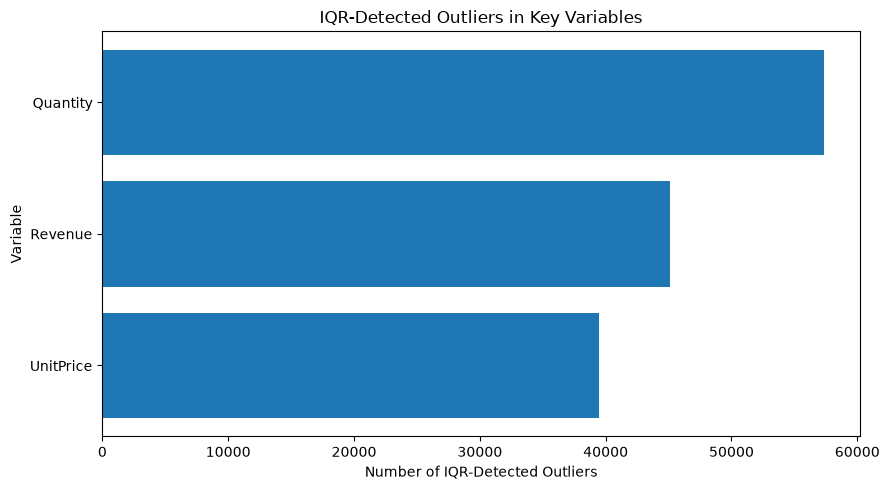

In [ ]:
# ============================================
# Step 23B: Outlier Count Visualization
# ============================================

outlier_counts = outlier_summary["Outlier Count"].sort_values()

plt.figure(figsize=(9, 5))

plt.barh(
    outlier_counts.index,
    outlier_counts.values
)

plt.xlabel("Number of IQR-Detected Outliers")
plt.ylabel("Variable")
plt.title("IQR-Detected Outliers in Key Variables")

plt.tight_layout()
plt.show()

### Outlier Analysis — Observations and Inferences

**Observation:**  
The IQR method identifies observations that fall outside the statistical lower and upper bounds for Quantity, UnitPrice, and Revenue.

**Effect on Central Tendency:**  
A noticeable difference between the mean and median indicates that extreme observations may influence the mean. Comparing the original and IQR-filtered statistics helps quantify this influence.

**Why Outliers Were Not Automatically Removed:**  
An IQR-based statistical outlier is not necessarily an invalid business observation. In retail data, unusually large quantities, high-value products, or large orders may represent legitimate transactions.

**Business Implication:**  
Automatically removing extreme transactions could reduce the influence of unusual observations but may also remove legitimate high-value business activity. Therefore, outliers are investigated and quantified rather than permanently removed from the cleaned dataset.

**Analytical Decision:**  
The original dataset is retained for the primary analysis. IQR filtering is used only as a sensitivity analysis to understand how extreme observations affect descriptive statistics.

**Limitation:**  
The IQR method identifies statistical extremes but cannot determine whether an observation is a data-entry error or a legitimate business transaction without additional business context.

In [ ]:
# ============================================
# Step 24A: Prepare Groups for Hypothesis Testing
# ============================================

# Identify the two countries with the highest number of regular-sale transactions
top_two_countries = (
    positive_sales["Country"]
    .value_counts()
    .head(2)
    .index
    .tolist()
)

country_1 = top_two_countries[0]
country_2 = top_two_countries[1]

print("Countries selected for hypothesis testing:")
print(f"Group 1: {country_1}")
print(f"Group 2: {country_2}")

# Calculate order-level revenue
country_orders = (
    positive_sales[
        positive_sales["Country"].isin(top_two_countries)
    ]
    .groupby(["Country", "InvoiceNo"])
    .agg(
        Order_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

group_1 = country_orders[
    country_orders["Country"] == country_1
]["Order_Revenue"]

group_2 = country_orders[
    country_orders["Country"] == country_2
]["Order_Revenue"]

print(f"\n{country_1} orders: {len(group_1):,}")
print(f"{country_2} orders: {len(group_2):,}")

print(f"\n{country_1} median order value: {group_1.median():,.2f}")
print(f"{country_2} median order value: {group_2.median():,.2f}")

Countries selected for hypothesis testing:
Group 1: United Kingdom
Group 2: Germany

United Kingdom orders: 18,019
Germany orders: 457

United Kingdom median order value: 299.95
Germany median order value: 354.85


In [ ]:
# ============================================
# Step 24B: Mann–Whitney U Hypothesis Test
# ============================================

# Null Hypothesis (H0):
# The order-value distributions of the two countries are the same.

# Alternative Hypothesis (H1):
# The order-value distributions of the two countries are different.

u_statistic, p_value = stats.mannwhitneyu(
    group_1,
    group_2,
    alternative="two-sided"
)

alpha = 0.05

print("Mann–Whitney U Test")
print("=" * 40)

print(f"Country 1: {country_1}")
print(f"Country 2: {country_2}")
print(f"U Statistic: {u_statistic:,.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance Level (α): {alpha}")

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "There is statistically significant evidence "
        "that the order-value distributions differ."
    )
else:
    print("\nDecision: Fail to Reject H0")
    print(
        "There is insufficient statistical evidence "
        "to conclude that the order-value distributions differ."
    )

Mann–Whitney U Test
Country 1: United Kingdom
Country 2: Germany
U Statistic: 3,489,572.50
P-value: 0.000000
Significance Level (α): 0.05

Decision: Reject H0
There is statistically significant evidence that the order-value distributions differ.


### Hypothesis Testing — Interpretation

**Research Question:**  
Do the order-value distributions differ between the two countries with the highest number of regular-sale transactions?

**Null Hypothesis (H₀):**  
There is no statistically significant difference between the order-value distributions of the two selected countries.

**Alternative Hypothesis (H₁):**  
The order-value distributions are statistically different between the two selected countries.

**Why Mann–Whitney U Test?**  
Retail order values are typically skewed and may contain extreme observations. The Mann–Whitney U test is a non-parametric alternative that does not require the two groups to follow a normal distribution.

**Decision Rule:**  
At a significance level of α = 0.05:
- If p-value < 0.05, reject H₀.
- If p-value ≥ 0.05, fail to reject H₀.

**Practical Interpretation:**  
A statistically significant result indicates evidence of a difference in the order-value distributions. However, statistical significance does not by itself establish that the difference is practically or commercially important.

**Important Limitation:**  
The two countries were selected based on transaction volume in this dataset. Therefore, this test describes a relationship within the available dataset and should not be generalized automatically to other markets or future periods.

**Caution:**  
The test identifies an association between country and order-value distribution. It does not establish that country itself causes differences in order value.

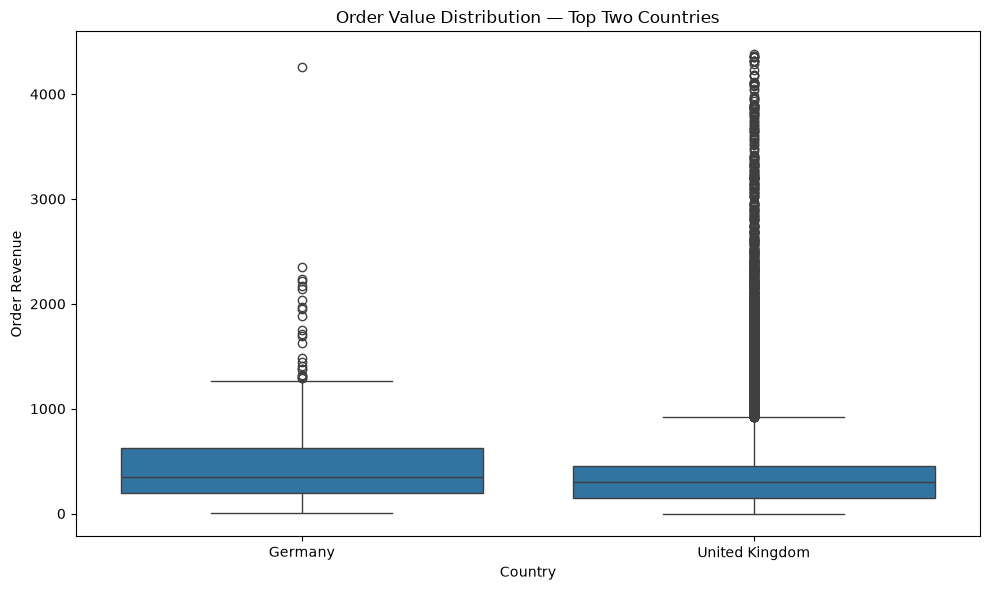

In [ ]:
# ============================================
# Step 24C: Visual Comparison of Order Values
# ============================================

plot_data = country_orders.copy()

# Limit extreme values only for visualization
upper_limit = plot_data["Order_Revenue"].quantile(0.99)

plot_data = plot_data[
    plot_data["Order_Revenue"] <= upper_limit
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=plot_data,
    x="Country",
    y="Order_Revenue"
)

plt.title(
    "Order Value Distribution — Top Two Countries"
)

plt.xlabel("Country")
plt.ylabel("Order Revenue")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Step 25: Hypothesis Test — Effect Size
# ============================================

# Rank-biserial correlation as an effect-size measure
n1 = len(group_1)
n2 = len(group_2)

rank_biserial = 1 - (
    (2 * u_statistic) / (n1 * n2)
)

print("Hypothesis Test Summary")
print("=" * 45)

print(f"Group 1: {country_1}")
print(f"Group 2: {country_2}")
print(f"Group 1 sample size: {n1:,}")
print(f"Group 2 sample size: {n2:,}")
print(f"U Statistic: {u_statistic:,.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Rank-biserial effect size: {rank_biserial:.4f}")

print("\nMedian Order Values:")
print(f"{country_1}: {group_1.median():,.2f}")
print(f"{country_2}: {group_2.median():,.2f}")

Hypothesis Test Summary
Group 1: United Kingdom
Group 2: Germany
Group 1 sample size: 18,019
Group 2 sample size: 457
U Statistic: 3,489,572.50
P-value: 0.000000
Rank-biserial effect size: 0.1525

Median Order Values:
United Kingdom: 299.95
Germany: 354.85


### Hypothesis Test — Statistical vs Practical Significance

The Mann–Whitney U test evaluates whether the order-value distributions of the two selected countries differ statistically.

The p-value determines whether there is sufficient statistical evidence to reject the null hypothesis at the 5% significance level.

However, statistical significance alone does not describe the magnitude of the difference. Therefore, the rank-biserial correlation is also reported as an effect-size measure.

The median order value is reported alongside the statistical test because retail order values can be highly skewed and the median is less sensitive to extreme observations.

**Interpretation Principle:**

- A small p-value indicates statistical evidence of a difference.
- A larger effect size indicates a more substantial difference between the groups.
- Statistical significance should not automatically be interpreted as commercial importance.
- The result describes the observed dataset and does not establish causation.

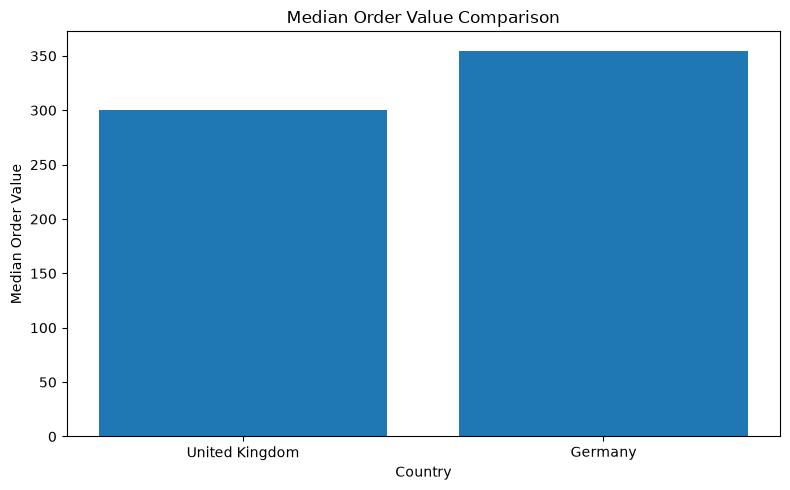

In [ ]:
# ============================================
# Step 25B: Median Order Value Comparison
# ============================================

median_values = pd.Series({
    country_1: group_1.median(),
    country_2: group_2.median()
})

plt.figure(figsize=(8, 5))

plt.bar(
    median_values.index,
    median_values.values
)

plt.title("Median Order Value Comparison")
plt.xlabel("Country")
plt.ylabel("Median Order Value")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Step 26: Key Business Metrics
# ============================================

total_revenue = df["Revenue"].sum()
regular_revenue = positive_sales["Revenue"].sum()
negative_revenue = negative_transactions["Revenue"].sum()

total_transactions = len(df)
regular_transactions = len(positive_sales)
negative_transaction_count = len(negative_transactions)

top_product_name = top_products.iloc[0]["Description"]
top_product_revenue = top_products.iloc[0]["Revenue"]

top_country_name = country_sales.iloc[0]["Country"]
top_country_revenue = country_sales.iloc[0]["Revenue"]

print("KEY BUSINESS METRICS")
print("=" * 50)

print(f"Total dataset transactions: {total_transactions:,}")
print(f"Regular sales transactions: {regular_transactions:,}")
print(f"Negative-quantity transactions: {negative_transaction_count:,}")

print(f"\nRegular sales revenue: {regular_revenue:,.2f}")
print(f"Negative transaction impact: {negative_revenue:,.2f}")
print(f"Net recorded revenue: {total_revenue:,.2f}")

print(f"\nTop product by revenue: {top_product_name}")
print(f"Top product revenue: {top_product_revenue:,.2f}")

print(f"\nTop country by revenue: {top_country_name}")
print(f"Top country revenue: {top_country_revenue:,.2f}")

print(f"\nOverall AOV: {overall_aov:,.2f}")

KEY BUSINESS METRICS
Total dataset transactions: 534,129
Regular sales transactions: 524,878
Negative-quantity transactions: 9,251

Regular sales revenue: 10,642,110.80
Negative transaction impact: -893,979.73
Net recorded revenue: 9,748,131.07

Top product by revenue: DOTCOM POSTAGE
Top product revenue: 206,248.77

Top country by revenue: United Kingdom
Top country revenue: 9,001,744.09

Overall AOV: 479.56


In [ ]:
# ============================================
# Step 26B: Top 5 Products and Countries
# ============================================

print("Top 5 Products by Revenue")
print("=" * 40)
display(
    top_products[
        ["Description", "Transactions", "Quantity_Sold", "Revenue"]
    ].head(5)
)

print("\nTop 5 Countries by Revenue")
print("=" * 40)
display(
    country_sales[
        ["Country", "Transactions", "Quantity_Sold", "Revenue"]
    ].head(5)
)

Top 5 Products by Revenue


,Description,Transactions,Quantity_Sold,Revenue
4150,DOTCOM POSTAGE,706,706,206248.77
1340,REGENCY CAKESTAND 3 TIER,2007,13851,174156.54
2668,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
3640,WHITE HANGING HEART T-LIGHT HOLDER,2244,37580,104284.24
2877,PARTY BUNTING,1699,18283,99445.23



Top 5 Countries by Revenue


,Country,Transactions,Quantity_Sold,Revenue
36,United Kingdom,479985,4646906,9001744.094
24,Netherlands,2359,200361,285446.340
10,EIRE,7879,147007,283140.520
14,Germany,9025,119154,228678.400
13,France,8392,112060,209625.370


# Key Findings and Business Insights

### 1. Transaction and Revenue Structure

The dataset contains a large number of retail transaction records. Regular positive-quantity transactions represent normal sales activity, while negative-quantity transactions have been retained because they may represent returns, cancellations, or transaction reversals.

### 2. Negative Quantity Transactions

Negative-quantity transactions create a measurable reduction in recorded revenue. Treating them as invalid and removing them would potentially overstate sales performance.

Therefore, the analysis separates regular sales activity from negative transactions while retaining both in the original cleaned dataset.

### 3. Outlier Behaviour

Quantity, UnitPrice, and Revenue contain statistically extreme observations according to the IQR method.

These observations were investigated rather than automatically removed because unusual retail transactions can represent legitimate bulk purchases, expensive products, or high-value orders.

IQR filtering was used only as a sensitivity analysis to understand the influence of extreme observations.

### 4. Sales Distribution

The distributions of retail variables show that transaction data can contain substantial variation and skewness. Therefore, median-based measures and non-parametric statistical methods can provide useful complementary information alongside the mean.

### 5. Product-Level Insights

The product analysis identifies products contributing the highest recorded revenue among positive-quantity transactions.

Revenue concentration can indicate that a relatively small group of products contributes substantially to recorded sales.

### 6. Country-Level Insights

Country-level analysis shows differences in transaction activity, quantity sold, and recorded revenue across markets.

These differences describe the observed dataset and should not automatically be interpreted as differences in profitability or long-term market potential.

### 7. Customer Behaviour

Customer-level analysis was restricted to records with an available CustomerID. Average Order Value was calculated at the invoice level to provide a more meaningful measure of typical order value.

Records with missing CustomerID were not assigned to customers because reliable identification could not be inferred from the available data.

### 8. Time-Based Patterns

Monthly and day-of-week analysis provides information about changes in transaction activity during the observation period.

These patterns can be useful for identifying periods of higher or lower recorded sales activity, although the dataset covers a specific historical period and cannot automatically represent future behaviour.

### 9. Hypothesis Testing

The Mann–Whitney U test was used to compare order-value distributions between the two countries with the highest transaction counts.

The test result should be interpreted using both statistical significance and effect size. Statistical significance indicates evidence of a distributional difference, while effect size provides information about the magnitude of that difference.

### 10. Overall Analytical Conclusion

The EDA demonstrates that retail transaction data contains multiple dimensions of business information, including sales activity, returns or reversals, product performance, geographic distribution, customer behaviour, temporal patterns, and statistical variation.

The analysis therefore avoids treating data-cleaning decisions as purely technical operations. Each decision is evaluated according to its potential effect on business interpretation and downstream analysis.

# Assumptions, Limitations and Data-Handling Decisions

## 1. Negative Quantity Transactions

Negative quantities were retained rather than automatically removed.

### Reasoning

Negative quantities may represent returns, cancellations, credit transactions, or other reversals. The available dataset does not contain sufficient information to classify every negative transaction with certainty.

### Analytical Implication

Removing these observations could overstate sales activity and eliminate potentially meaningful business events.

Therefore:

- Negative transactions are retained in the cleaned dataset.
- Regular sales analysis uses positive-quantity transactions.
- Negative transactions are analyzed separately.
- Net revenue analysis can incorporate both positive and negative revenue.

---

## 2. Outliers

IQR-based methods were used to identify statistical outliers in Quantity, UnitPrice, and Revenue.

### Reasoning

A statistical outlier is not necessarily a data error. In retail data, unusually large quantities or high-value transactions may represent legitimate business activity.

### Analytical Implication

Automatically removing outliers could result in loss of genuine business information.

Therefore, outliers were investigated and their influence on descriptive statistics was evaluated rather than permanently removed.

---

## 3. Missing CustomerID

CustomerID values were not artificially filled or inferred.

### Reasoning

There is insufficient information to reliably determine which customer a missing CustomerID belongs to.

### Analytical Implication

Customer-level analysis represents only transactions with an available CustomerID.

This limitation should be considered when interpreting customer metrics such as customer revenue and Average Order Value.

---

## 4. Revenue Calculation

Revenue was calculated as:

**Revenue = Quantity × UnitPrice**

Negative quantities therefore produce negative revenue values.

### Analytical Implication

Revenue is a transaction-level monetary measure in this analysis. It should not be interpreted as profit because product costs, operating expenses, shipping costs, and other business costs are unavailable.

---

## 5. Positive-Quantity Sales Analysis

Positive-quantity transactions were used for regular sales analysis.

### Reasoning

Negative quantities may represent transaction reversals and should not be mixed directly with regular sales activity when examining sales trends, product performance, or country-level regular sales.

---

## 6. Correlation Analysis

Correlation was used to identify associations between numerical variables.

### Limitation

Correlation does not establish causation.

Additionally, Revenue is mathematically derived from Quantity and UnitPrice. Therefore, correlations involving Revenue must be interpreted with caution because part of the relationship is created by the revenue formula itself.

---

## 7. Hypothesis Testing

The Mann–Whitney U test was selected because retail order values can be highly skewed and may contain extreme observations.

### Interpretation

A statistically significant result indicates evidence of a difference between the observed distributions, but statistical significance does not necessarily imply practical or commercial importance.

The analysis also considers effect size and median order values.

---

## 8. Generalization

The findings describe the available Online Retail dataset and its specific observation period.

The results should not automatically be generalized to:

- Other retail businesses
- Other countries or markets
- Different time periods
- Future customer behaviour

Additional datasets and longer observation periods would be required for broader generalization.

---

## 9. Reproducibility

The analysis is performed using Python, pandas, NumPy, Matplotlib, Seaborn, SciPy, and the Week 1 cleaned dataset.

Random sampling used for visualization is controlled with `random_state=42` to make the analysis reproducible.

---

## Overall Data-Handling Principle

The primary objective was not simply to remove unusual or incomplete observations.

Instead, each data-handling decision was evaluated based on:

**Observed Data → Reason for Decision → Alternative → Analytical Impact → Business Interpretation**

This approach helps preserve potentially meaningful information while making the assumptions and limitations of the analysis explicit.

In [51]:
# ============================================
# Step 30A: Final Report Metrics
# ============================================

# --------------------------------------------
# 1. Prepare Sales Data
# --------------------------------------------

regular_sales_final = df[df["Quantity"] > 0].copy()
negative_transactions_final = df[df["Quantity"] < 0].copy()


# --------------------------------------------
# 2. Customer / Order Analysis
# --------------------------------------------

customer_sales_final = regular_sales_final[
    regular_sales_final["CustomerID"].notna()
].copy()

order_level_final = (
    customer_sales_final
    .groupby(["CustomerID", "InvoiceNo"])
    .agg(
        Order_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

total_customer_revenue = order_level_final["Order_Revenue"].sum()
total_customer_orders = order_level_final["InvoiceNo"].nunique()

overall_aov_final = (
    total_customer_revenue / total_customer_orders
    if total_customer_orders > 0
    else 0
)

identified_customers = (
    customer_sales_final["CustomerID"].nunique()
)


# --------------------------------------------
# 3. Product Analysis
# --------------------------------------------

top_products_final = (
    regular_sales_final
    .groupby(["StockCode", "Description"])
    .agg(
        Transactions=("InvoiceNo", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)


# --------------------------------------------
# 4. Country Analysis
# --------------------------------------------

country_sales_final = (
    regular_sales_final
    .groupby("Country")
    .agg(
        Transactions=("InvoiceNo", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)


# --------------------------------------------
# 5. Hypothesis Test — Recalculate Safely
# --------------------------------------------

top_two_countries_final = (
    regular_sales_final["Country"]
    .value_counts()
    .head(2)
    .index
    .tolist()
)

country_1_final = top_two_countries_final[0]
country_2_final = top_two_countries_final[1]

country_orders_final = (
    regular_sales_final[
        regular_sales_final["Country"].isin(
            top_two_countries_final
        )
    ]
    .groupby(["Country", "InvoiceNo"])
    .agg(
        Order_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

group_1_final = country_orders_final[
    country_orders_final["Country"] == country_1_final
]["Order_Revenue"]

group_2_final = country_orders_final[
    country_orders_final["Country"] == country_2_final
]["Order_Revenue"]

u_statistic_final, p_value_final = stats.mannwhitneyu(
    group_1_final,
    group_2_final,
    alternative="two-sided"
)

n1_final = len(group_1_final)
n2_final = len(group_2_final)

rank_biserial_final = 1 - (
    (2 * u_statistic_final)
    / (n1_final * n2_final)
)


# ============================================
# FINAL REPORT OUTPUT
# ============================================

print("=" * 60)
print("WEEK 2 EDA — FINAL REPORT METRICS")
print("=" * 60)


# Dataset
print("\nDATASET")
print("-" * 40)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")


# Negative quantities
print("\nNEGATIVE QUANTITY ANALYSIS")
print("-" * 40)

negative_count_final = len(negative_transactions_final)

negative_percentage_final = (
    negative_count_final / len(df)
) * 100

print(
    f"Negative transactions: "
    f"{negative_count_final:,}"
)

print(
    f"Negative transaction %: "
    f"{negative_percentage_final:.2f}%"
)

print(
    f"Negative quantity total: "
    f"{negative_transactions_final['Quantity'].sum():,.2f}"
)

print(
    f"Negative revenue impact: "
    f"{negative_transactions_final['Revenue'].sum():,.2f}"
)


# Revenue
print("\nREVENUE")
print("-" * 40)

regular_revenue_final = (
    regular_sales_final["Revenue"].sum()
)

net_revenue_final = df["Revenue"].sum()

print(
    f"Regular sales revenue: "
    f"{regular_revenue_final:,.2f}"
)

print(
    f"Net recorded revenue: "
    f"{net_revenue_final:,.2f}"
)


# Customer / AOV
print("\nCUSTOMER / AOV")
print("-" * 40)

print(
    f"Customers with CustomerID: "
    f"{identified_customers:,}"
)

print(
    f"Total identified-customer orders: "
    f"{total_customer_orders:,}"
)

print(
    f"Total identified-customer revenue: "
    f"{total_customer_revenue:,.2f}"
)

print(
    f"Overall AOV: "
    f"{overall_aov_final:,.2f}"
)


# Top Product
print("\nTOP PRODUCT")
print("-" * 40)

print(
    f"Product: "
    f"{top_products_final.iloc[0]['Description']}"
)

print(
    f"Revenue: "
    f"{top_products_final.iloc[0]['Revenue']:,.2f}"
)


# Top Country
print("\nTOP COUNTRY")
print("-" * 40)

print(
    f"Country: "
    f"{country_sales_final.iloc[0]['Country']}"
)

print(
    f"Revenue: "
    f"{country_sales_final.iloc[0]['Revenue']:,.2f}"
)


# Hypothesis Test
print("\nHYPOTHESIS TEST")
print("-" * 40)

print(f"Country 1: {country_1_final}")
print(f"Country 2: {country_2_final}")

print(
    f"{country_1_final} orders: "
    f"{n1_final:,}"
)

print(
    f"{country_2_final} orders: "
    f"{n2_final:,}"
)

print(
    f"{country_1_final} median order value: "
    f"{group_1_final.median():,.2f}"
)

print(
    f"{country_2_final} median order value: "
    f"{group_2_final.median():,.2f}"
)

print(
    f"U Statistic: "
    f"{u_statistic_final:,.2f}"
)

print(
    f"P-value: "
    f"{p_value_final:.6f}"
)

print(
    f"Rank-biserial effect size: "
    f"{rank_biserial_final:.4f}"
)

if p_value_final < 0.05:
    print(
        "Decision: Reject H0 at the 5% significance level."
    )
else:
    print(
        "Decision: Fail to reject H0 at the 5% significance level."
    )


print("\n" + "=" * 60)
print("FINAL METRICS COMPLETE")
print("=" * 60)

WEEK 2 EDA — FINAL REPORT METRICS

DATASET
----------------------------------------
Rows: 534,129
Columns: 12
Duplicate rows: 0

NEGATIVE QUANTITY ANALYSIS
----------------------------------------
Negative transactions: 9,251
Negative transaction %: 1.73%
Negative quantity total: -275,560.00
Negative revenue impact: -893,979.73

REVENUE
----------------------------------------
Regular sales revenue: 10,642,110.80
Net recorded revenue: 9,748,131.07

CUSTOMER / AOV
----------------------------------------
Customers with CustomerID: 4,338
Total identified-customer orders: 18,532
Total identified-customer revenue: 8,887,208.89
Overall AOV: 479.56

TOP PRODUCT
----------------------------------------
Product: DOTCOM POSTAGE
Revenue: 206,248.77

TOP COUNTRY
----------------------------------------
Country: United Kingdom
Revenue: 9,001,744.09

HYPOTHESIS TEST
----------------------------------------
Country 1: United Kingdom
Country 2: Germany
United Kingdom orders: 18,019
Germany orders: 45

In [52]:
# ============================================
# Step 30B: Remaining Report Values
# ============================================

print("TOP PRODUCT")
print("-" * 40)
print(f"Product: {top_products_final.iloc[0]['Description']}")
print(f"Revenue: {top_products_final.iloc[0]['Revenue']:,.2f}")

print("\nTOP COUNTRY")
print("-" * 40)
print(f"Country: {country_sales_final.iloc[0]['Country']}")
print(f"Revenue: {country_sales_final.iloc[0]['Revenue']:,.2f}")

print("\nCUSTOMER / AOV")
print("-" * 40)
print(f"Identified customers: {identified_customers:,}")
print(f"Identified-customer orders: {total_customer_orders:,}")
print(f"Identified-customer revenue: {total_customer_revenue:,.2f}")
print(f"Overall AOV: {overall_aov_final:,.2f}")

print("\nHYPOTHESIS TEST")
print("-" * 40)
print(f"Country 1: {country_1_final}")
print(f"Country 2: {country_2_final}")
print(f"{country_1_final} orders: {n1_final:,}")
print(f"{country_2_final} orders: {n2_final:,}")
print(f"{country_1_final} median: {group_1_final.median():,.2f}")
print(f"{country_2_final} median: {group_2_final.median():,.2f}")
print(f"U Statistic: {u_statistic_final:,.2f}")
print(f"P-value: {p_value_final:.6f}")
print(f"Effect Size: {rank_biserial_final:.4f}")

TOP PRODUCT
----------------------------------------
Product: DOTCOM POSTAGE
Revenue: 206,248.77

TOP COUNTRY
----------------------------------------
Country: United Kingdom
Revenue: 9,001,744.09

CUSTOMER / AOV
----------------------------------------
Identified customers: 4,338
Identified-customer orders: 18,532
Identified-customer revenue: 8,887,208.89
Overall AOV: 479.56

HYPOTHESIS TEST
----------------------------------------
Country 1: United Kingdom
Country 2: Germany
United Kingdom orders: 18,019
Germany orders: 457
United Kingdom median: 299.95
Germany median: 354.85
U Statistic: 3,489,572.50
P-value: 0.000000
Effect Size: 0.1525
